# 🚗 AutoEstima — Exploratory Data Analysis
Anàlisi exploratòria del dataset de cotxes de segona mà.


## 1. Càrrega de dades

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estil dels gràfics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/coches_processed.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (82372, 10)


,make,model,months_old,power,sale_type,num_owners,gear_type,fuel_type,kms,price
0,renault,kangoo,145,59,used,1,manual,diesel,200000,200000
1,porsche,panamera,5,500,used,1,automatic,hybrid,10000,199900
2,porsche,911,6,368,used,1,automatic,gasoline,50,199900
3,porsche,panamera,2,404,used,1,automatic,gasoline,3000,199500
4,bentley,continental,21,467,used,1,automatic,gasoline,16000,199000


## 2. Informació general

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82372 entries, 0 to 82371
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   make        82372 non-null  object
 1   model       82372 non-null  object
 2   months_old  82372 non-null  int64 
 3   power       82372 non-null  int64 
 4   sale_type   82372 non-null  object
 5   num_owners  82372 non-null  int64 
 6   gear_type   82372 non-null  object
 7   fuel_type   82372 non-null  object
 8   kms         82372 non-null  int64 
 9   price       82372 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 6.3+ MB


In [4]:
df.describe()

,months_old,power,num_owners,kms,price
count,82372.000000,82372.000000,82372.000000,82372.000000,82372.000000
mean,65.184577,100.419803,1.015114,85625.800199,16565.158379
std,57.862369,43.041870,0.147174,77041.076669,14338.051745
min,1.000000,0.000000,1.000000,0.000000,500.000000
25%,17.000000,77.000000,1.000000,18829.500000,8450.000000
50%,47.000000,88.000000,1.000000,69000.000000,13400.000000
75%,100.000000,110.000000,1.000000,134925.000000,20490.000000
max,374.000000,809.000000,11.000000,497000.000000,200000.000000


## 3. Distribució del preu (target)

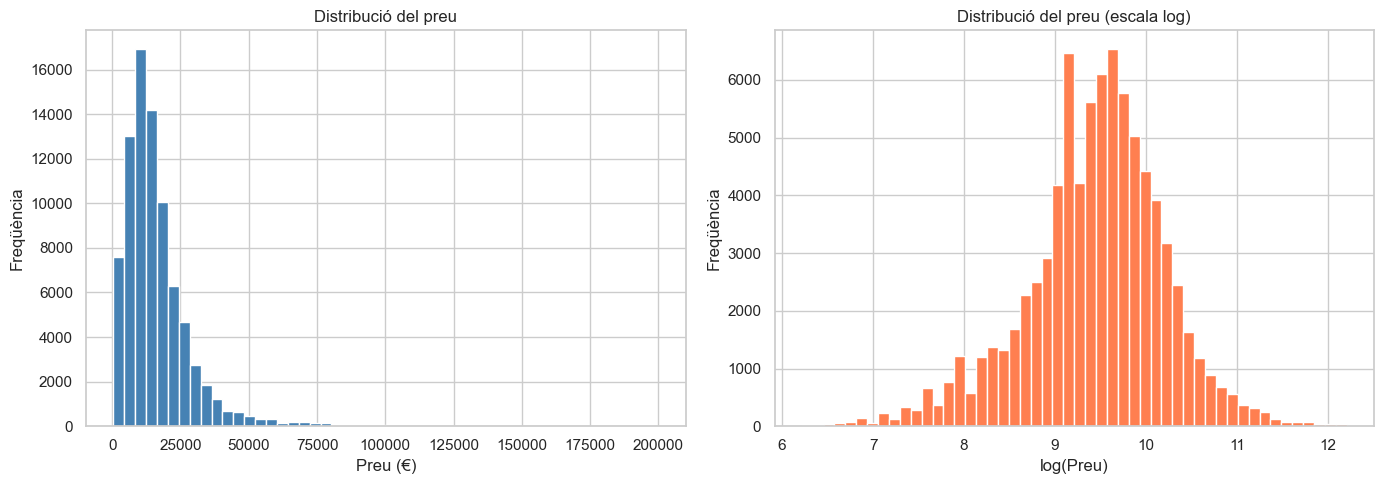

Preu mitjà: 16565€
Preu medià: 13400€
Preu mínim: 500€
Preu màxim: 200000€


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del preu
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribució del preu')
axes[0].set_xlabel('Preu (€)')
axes[0].set_ylabel('Freqüència')

# Log del preu (més llegible)
axes[1].hist(np.log1p(df['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribució del preu (escala log)')
axes[1].set_xlabel('log(Preu)')
axes[1].set_ylabel('Freqüència')

plt.tight_layout()
plt.show()

print(f'Preu mitjà: {df["price"].mean():.0f}€')
print(f'Preu medià: {df["price"].median():.0f}€')
print(f'Preu mínim: {df["price"].min()}€')
print(f'Preu màxim: {df["price"].max()}€')

## 4. Preu per combustible

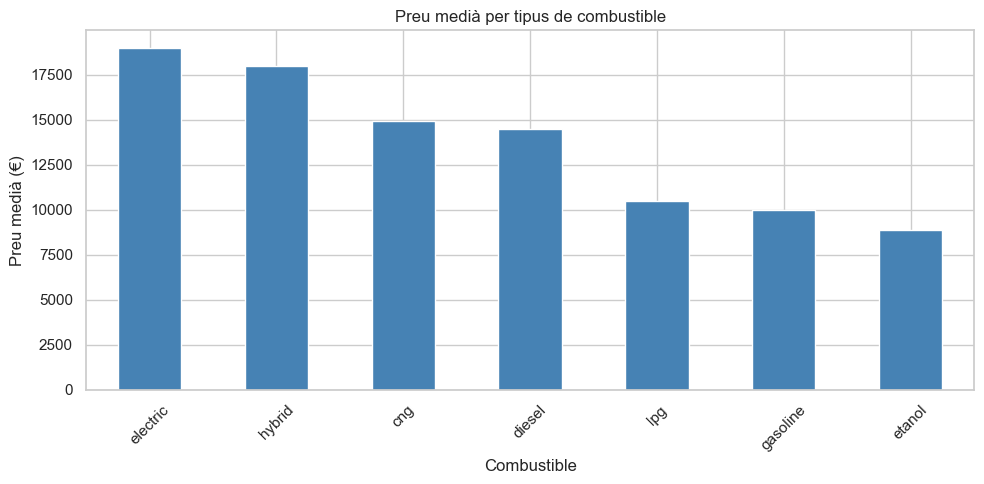

In [6]:
plt.figure(figsize=(10, 5))
df.groupby('fuel_type')['price'].median().sort_values(ascending=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Preu medià per tipus de combustible')
plt.xlabel('Combustible')
plt.ylabel('Preu medià (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Preu per tipus de canvi

C:\Users\polga\AppData\Local\Temp\ipykernel_9008\3410038318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gear_type', y='price', palette='Set2')


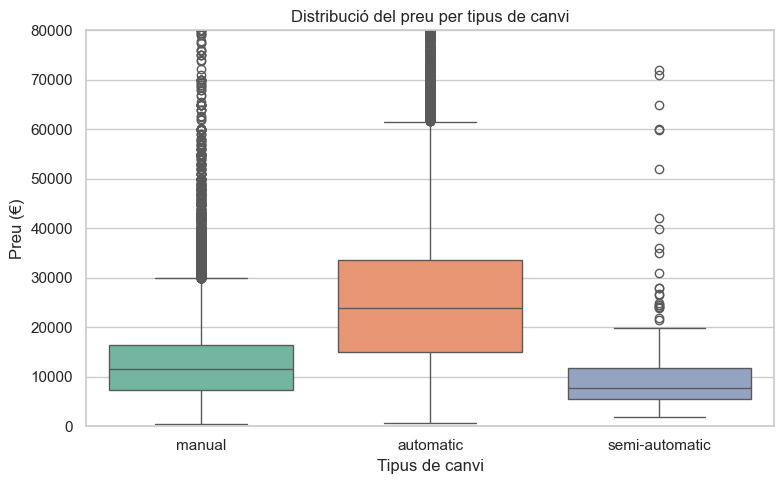

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gear_type', y='price', palette='Set2')
plt.title('Distribució del preu per tipus de canvi')
plt.xlabel('Tipus de canvi')
plt.ylabel('Preu (€)')
plt.ylim(0, 80000)
plt.tight_layout()
plt.show()

## 6. Top 15 marques per nombre d'anuncis

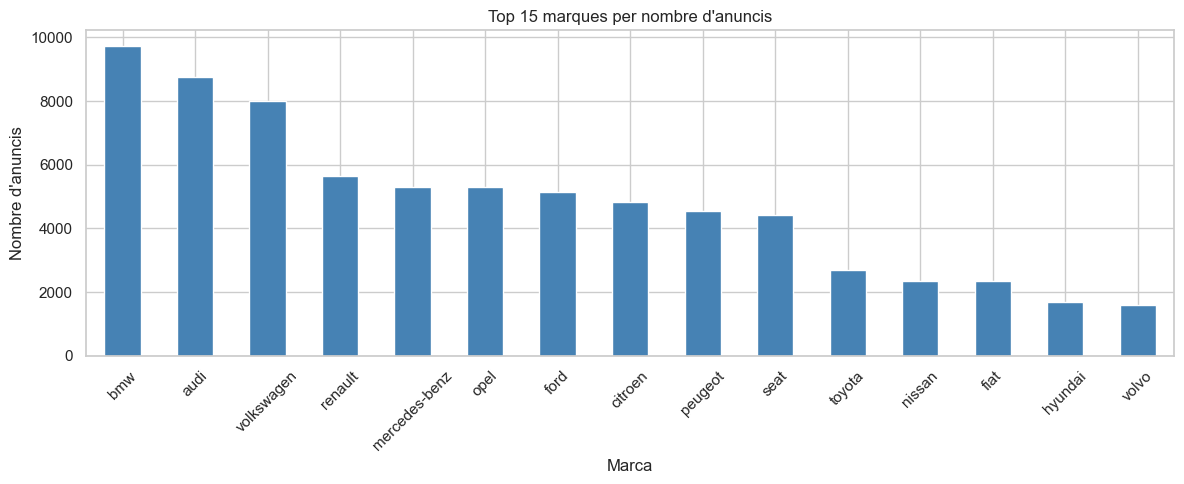

In [8]:
plt.figure(figsize=(12, 5))
df['make'].value_counts().head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 marques per nombre d\'anuncis')
plt.xlabel('Marca')
plt.ylabel('Nombre d\'anuncis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Preu per marca (Top 15)

C:\Users\polga\AppData\Local\Temp\ipykernel_9008\4158192809.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top15, x='make', y='price', order=order, palette='Blues_r')


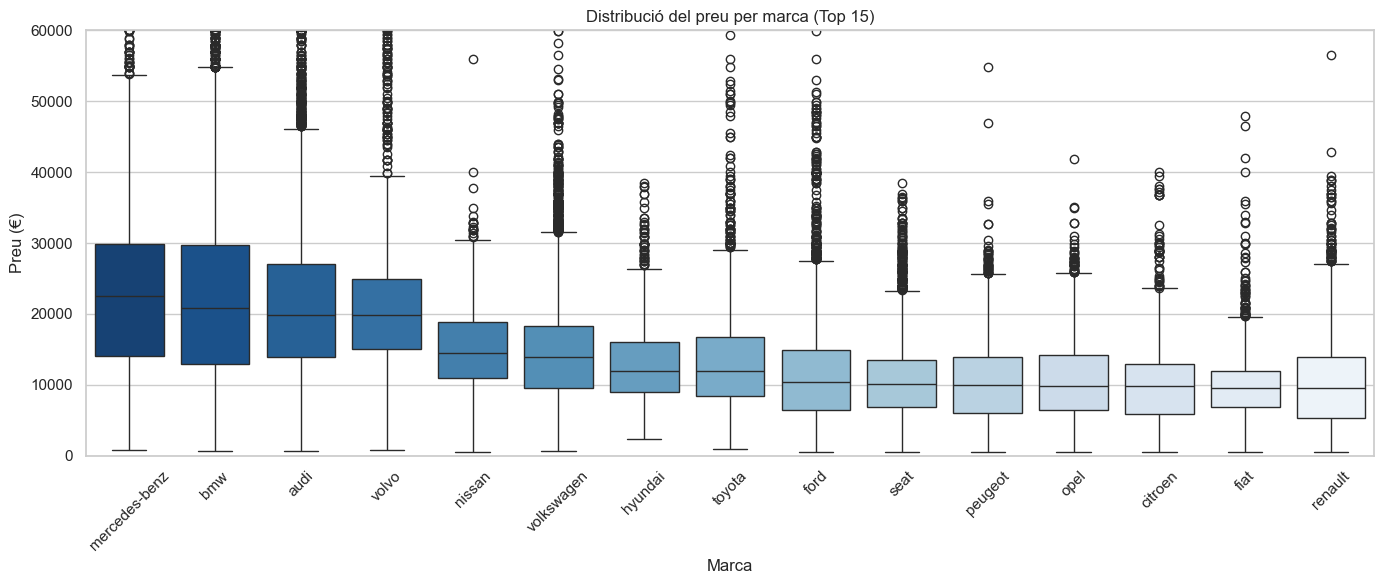

In [9]:
top15_makes = df['make'].value_counts().head(15).index
df_top15 = df[df['make'].isin(top15_makes)]

plt.figure(figsize=(14, 6))
order = df_top15.groupby('make')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top15, x='make', y='price', order=order, palette='Blues_r')
plt.title('Distribució del preu per marca (Top 15)')
plt.xlabel('Marca')
plt.ylabel('Preu (€)')
plt.ylim(0, 60000)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Correlació: quilometratge vs preu

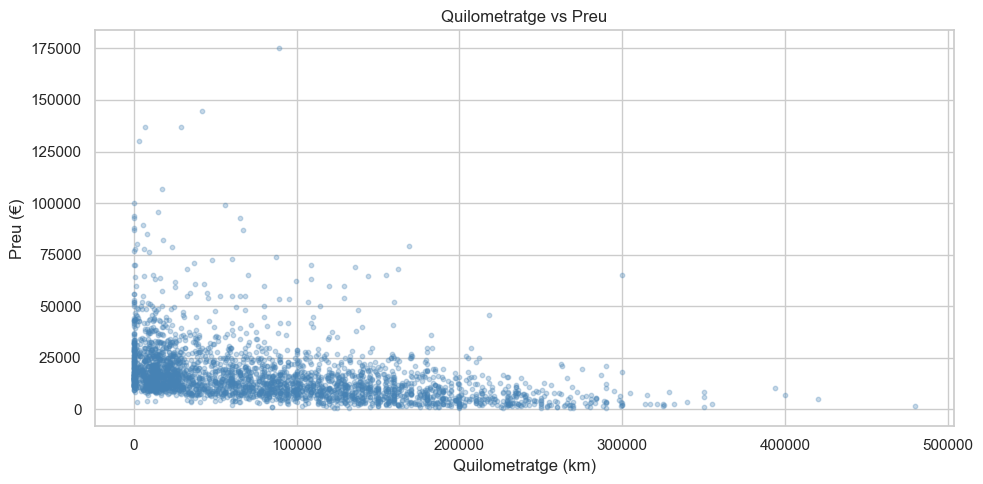

Correlació km-preu: -0.390


In [10]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['kms'], sample['price'], alpha=0.3, color='steelblue', s=10)
plt.title('Quilometratge vs Preu')
plt.xlabel('Quilometratge (km)')
plt.ylabel('Preu (€)')
plt.tight_layout()
plt.show()

corr = df['kms'].corr(df['price'])
print(f'Correlació km-preu: {corr:.3f}')

## 9. Correlació: antiguitat vs preu

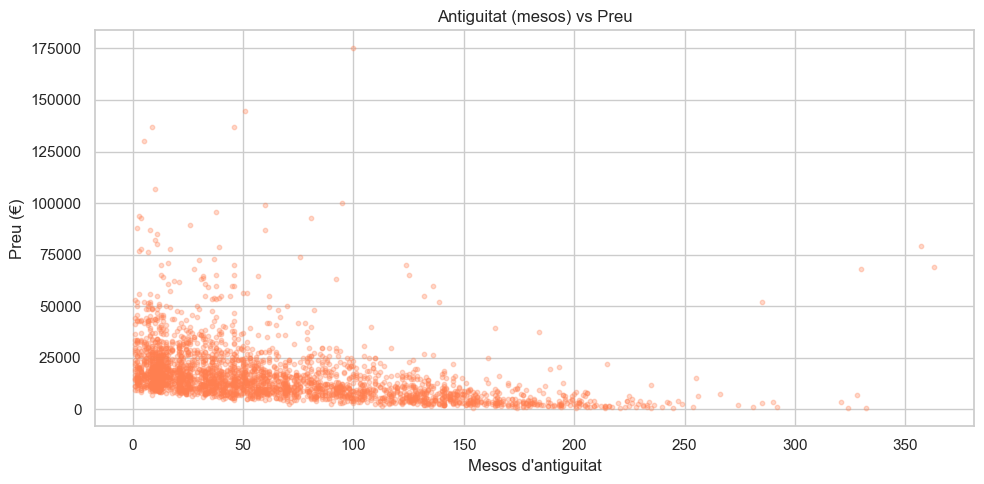

Correlació mesos-preu: -0.388


In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(sample['months_old'], sample['price'], alpha=0.3, color='coral', s=10)
plt.title('Antiguitat (mesos) vs Preu')
plt.xlabel('Mesos d\'antiguitat')
plt.ylabel('Preu (€)')
plt.tight_layout()
plt.show()

corr = df['months_old'].corr(df['price'])
print(f'Correlació mesos-preu: {corr:.3f}')

## 10. Matriu de correlació (variables numèriques)

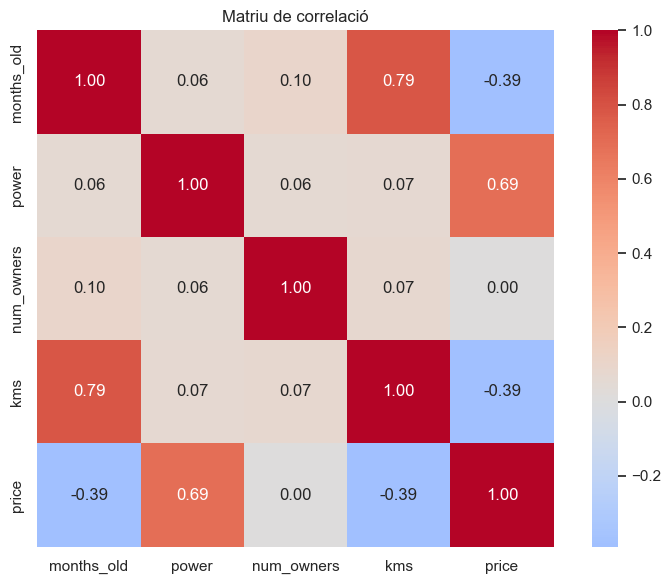

In [12]:
numeric_cols = ['months_old', 'power', 'num_owners', 'kms', 'price']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriu de correlació')
plt.tight_layout()
plt.show()

## 11. Conclusions de l'EDA

### Principals observacions:
- El **preu** té una distribució esbiaixada a la dreta → transformació log pot millorar el model
- El **quilometratge** i l'**antiguitat** tenen correlació negativa amb el preu (més km = més barat)
- La **potència** té correlació positiva amb el preu
- Els cotxes **automàtics** tendeixen a ser més cars que els manuals
- Els cotxes **híbrids i elèctrics** tenen preus mediàns superiors al dièsel/gasolina
- Les marques de luxe (Porsche, BMW, Mercedes) lideren els preus

### Variables seleccionades per al model ML:
- `make`, `model`, `fuel_type`, `gear_type`, `sale_type` → **categòriques** → One-Hot Encoding
- `months_old`, `power`, `kms`, `num_owners` → **numèriques** → StandardScaler
- `price` → **target** (variable a predir)
